In [1]:
from Model.CNNModel import DataLoader, NvidiaCNN
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import keras

In [2]:
path = Path(r"C:\Users\pc\Documents\GitHub\DPS920-Final\data\raw")
SPLIT = 0.2
SEED = 42
BATCH_SIZE = 256
IMG_SIZE = (200, 66)
BINS = np.arange(-0.5, 0.35, 0.05)
BIN_THRESHOLD = 200

In [3]:
train_ds = DataLoader(
    directory=path,
    subset="training",
    test_split=SPLIT,
    seed=SEED,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    bins=BINS,
    bin_threshold=BIN_THRESHOLD
)
val_ds = DataLoader(
    directory=path,
    subset="validation",
    test_split=SPLIT,
    seed=SEED,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    bins=BINS,
    bin_threshold=BIN_THRESHOLD
)

In [4]:
model = NvidiaCNN

In [5]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 31, 98, 24)     │         1,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 47, 36)     │        21,636 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 5, 22, 48)      │        43,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 3, 20, 64)      │        27,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 1, 18, 64)      │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1164)           │     1,342,092 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │       116,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           510 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,595,511 (6.09 MB)

 Trainable params: 1,595,511 (6.09 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
OPTIMIZER = keras.optimizers.Adam(learning_rate=0.001)
LOSS = "mse"
EPOCHS = 50

In [7]:
model.compile(optimizer=OPTIMIZER, loss=LOSS)

In [8]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss',patience=7,restore_best_weights=True)]
)

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 378ms/step - loss: 0.0240 - val_loss: 0.0065
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 328ms/step - loss: 0.0234 - val_loss: 0.0065
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 340ms/step - loss: 0.0233 - val_loss: 0.0065
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 337ms/step - loss: 0.0235 - val_loss: 0.0064
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 340ms/step - loss: 0.0216 - val_loss: 0.0058
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 341ms/step - loss: 0.0180 - val_loss: 0.0047
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 356ms/step - loss: 0.0187 - val_loss: 0.0050
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 329ms/step - loss: 0.0132 - val_loss: 0.0033
Epoch 9/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 325ms/step - loss: 0.0107 - val_loss: 0.0061
Epoch 10/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 331ms/step - loss: 0.0080 - val_loss: 0.0039
Epoch 11/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 323ms/step - loss: 0.0076 - val_loss: 0.0043
Epoch 12/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 328ms/step - loss: 0.0065 - val_lo

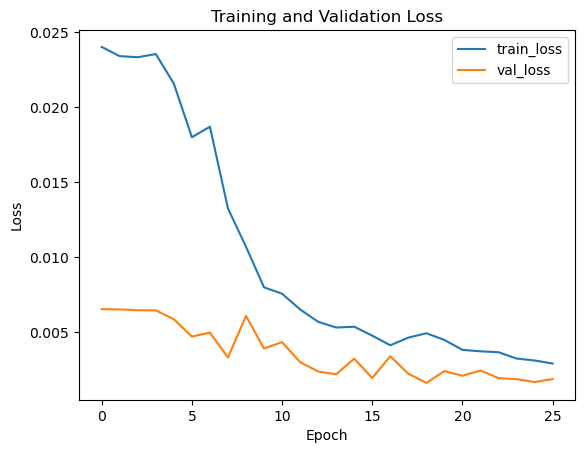

In [9]:
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [11]:
model.save(r"C:\Users\pc\Documents\GitHub\DPS920-Final\models\nvidia_cnn.keras")
model.save(r"C:\Users\pc\Documents\GitHub\DPS920-Final\models\nvidia_cnn.h5")